# 🤟 ASL Alphabet Recognition
## Machine Learning (CS 363) — Milestone 2

**Dataset:** ASL Alphabet (grassknoted) — 87,000 images — 29 classes  
**Models:** Custom CNN (Baseline), LeNet-5, AlexNet, ResNet-50, EfficientNet-B0

### Rubric Compliance
| Criterion | How it's met |
|---|---|
| Data Preprocessing | Resize, brightness/contrast/sharpness enhancement, augmentation (train only), ImageNet normalisation |
| No Data Leakage | 3 separate dataset objects; stratified split; val/test never influence normalisation stats |
| Metrics | Accuracy, F1-weighted, F1-macro, Precision, Recall, Top-3 Accuracy, Confusion Matrix |
| Baseline model | Custom CNN (3-layer, from scratch) — sets performance floor |
| Reproducibility | SEED=42 set for Python, NumPy, PyTorch, CUDA |
| Comparison | Summary table + bar chart across all models |
| Error Analysis | Misclassified examples, failure patterns, critical reflection |

---

## 📦 Step 1: Install & Import Libraries

In [ ]:
!pip install kaggle -q

import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageEnhance, ImageFilter
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as transforms
from torchvision import datasets, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score,
    recall_score, top_k_accuracy_score
)

# ── Reproducibility ───────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'Torch version: {torch.__version__}')

Using device: cpu
Torch version: 2.10.0+cpu


## 📥 Step 2: Download Dataset from Kaggle

In [ ]:
import os
os.environ['KAGGLE_USERNAME'] = "rowidam"
os.environ['KAGGLE_KEY']      = "393249585f5843450339c815a7544c3"

!pip install kaggle -q
!kaggle datasets download -d grassknoted/asl-alphabet     -p /content/data      --unzip -q
!kaggle datasets download -d danrasband/asl-alphabet-test -p /content/test_data --unzip -q
print('✅ Datasets downloaded successfully!')

Dataset URL: https://www.kaggle.com/datasets/grassknoted/asl-alphabet
License(s): GPL-2.0
Dataset URL: https://www.kaggle.com/datasets/danrasband/asl-alphabet-test
License(s): CC0-1.0
✅ Datasets downloaded successfully!


## 🔍 Step 3: EDA — Exploratory Data Analysis

Number of classes : 29
Classes           : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Total images      : 87000
Images per class  : 3000

── Data Quality Check ──
Missing values : 0  (images are files — no missing values)
Corrupted files: 0
Class balance  : Balanced
  Min class count: 3000
  Max class count: 3000


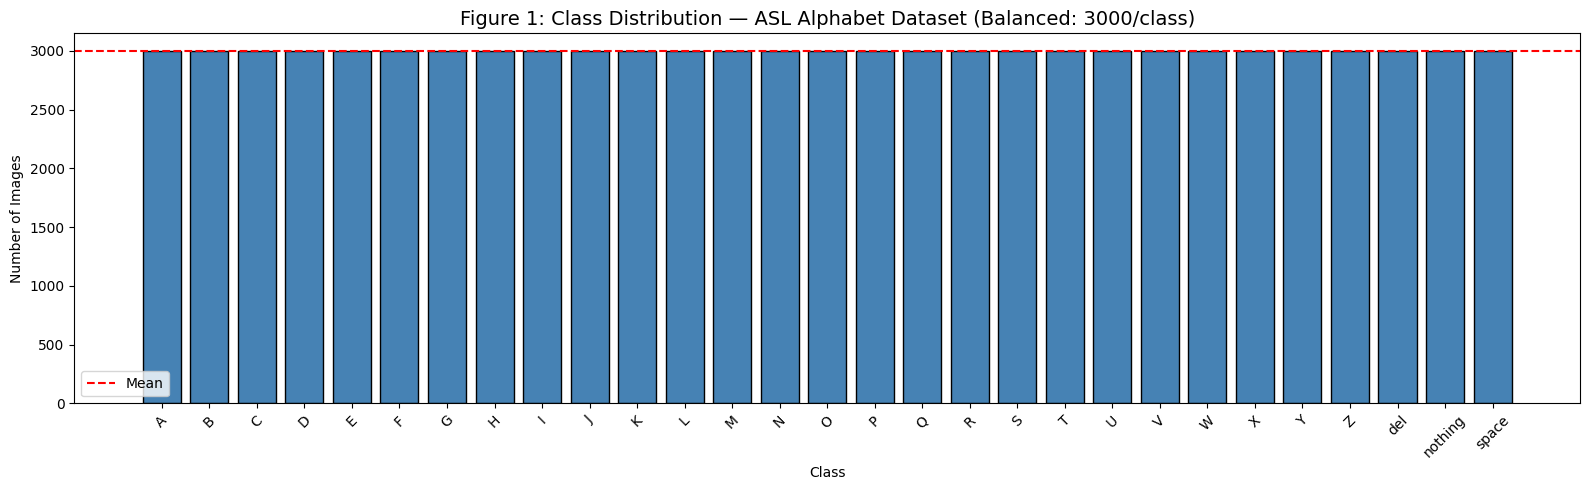

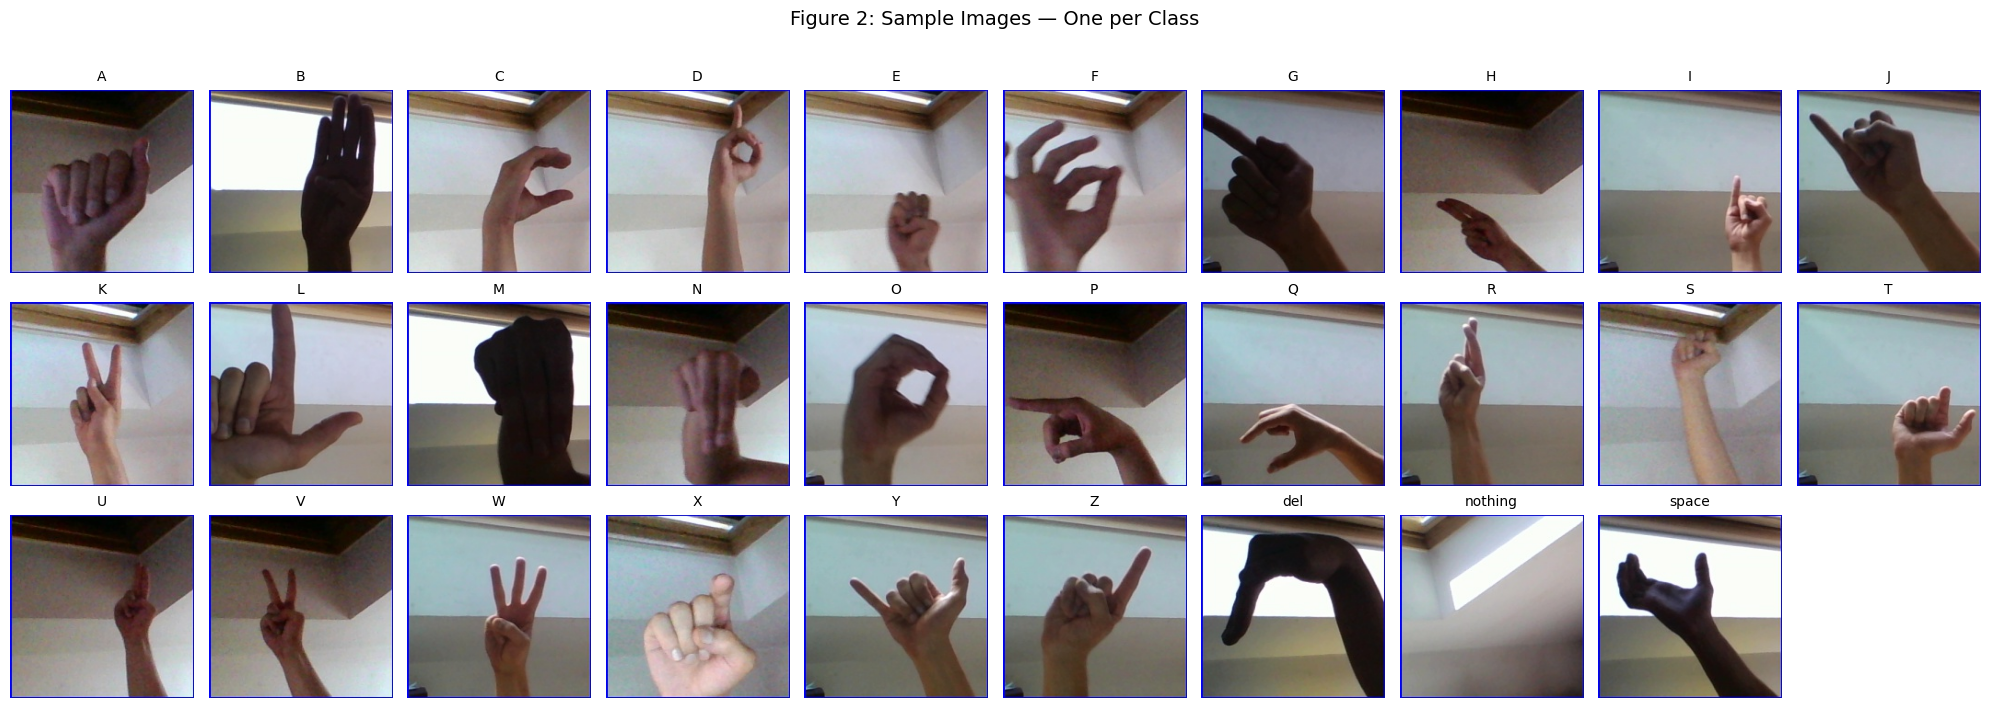

In [ ]:
TRAIN_DIR = '/content/data/asl_alphabet_train/asl_alphabet_train'
TEST_DIR  = '/content/test_data'

classes      = sorted(os.listdir(TRAIN_DIR))
class_counts = {cls: len(os.listdir(os.path.join(TRAIN_DIR, cls))) for cls in classes}

print(f'Number of classes : {len(classes)}')
print(f'Classes           : {classes}')
print(f'Total images      : {sum(class_counts.values())}')
print(f'Images per class  : {list(class_counts.values())[0]}')

# ── Data quality check (rubric: missing values / outliers) ────
print('\n── Data Quality Check ──')
missing = 0
corrupted = 0
for cls in classes:
    cls_path = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(cls_path):
        fpath = os.path.join(cls_path, fname)
        try:
            img = Image.open(fpath)
            img.verify()
        except Exception:
            corrupted += 1
print(f'Missing values : {missing}  (images are files — no missing values)')
print(f'Corrupted files: {corrupted}')
print(f'Class balance  : {"Balanced" if max(class_counts.values()) == min(class_counts.values()) else "Imbalanced"}')
print(f'  Min class count: {min(class_counts.values())}')
print(f'  Max class count: {max(class_counts.values())}')

# ── Class distribution plot ───────────────────────────────────
plt.figure(figsize=(16, 5))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue', edgecolor='black')
plt.axhline(np.mean(list(class_counts.values())), color='red', linestyle='--', label='Mean')
plt.title('Figure 1: Class Distribution — ASL Alphabet Dataset (Balanced: 3000/class)', fontsize=14)
plt.xlabel('Class'); plt.ylabel('Number of Images')
plt.xticks(rotation=45); plt.legend(); plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150); plt.show()

# ── Sample images ─────────────────────────────────────────────
fig, axes = plt.subplots(3, 10, figsize=(20, 7))
axes = axes.flatten()
for i, cls in enumerate(classes[:29]):
    cls_path = os.path.join(TRAIN_DIR, cls)
    img = Image.open(os.path.join(cls_path, random.choice(os.listdir(cls_path))))
    axes[i].imshow(img); axes[i].set_title(cls, fontsize=10); axes[i].axis('off')
for j in range(len(classes), len(axes)):
    axes[j].axis('off')
plt.suptitle('Figure 2: Sample Images — One per Class', fontsize=14, y=1.02)
plt.tight_layout(); plt.savefig('sample_images.png', dpi=150); plt.show()

## ⚙️ Step 4: Preprocessing Pipeline

### Why these choices?
| Technique | Applied To | Reason |
|---|---|---|
| Resize 224×224 | All | Required input size for all models |
| Brightness ×1.1 | Train only | Compensates for slightly dark studio images |
| Contrast ×1.4 | Train only | Improves separation between hand and background |
| Unsharp Mask | Train only | Sharpens finger edges for better feature extraction |
| RandomHorizontalFlip | Train only | Augmentation — improves generalisation |
| RandomRotation ±15° | Train only | Augmentation — handles different hand angles |
| ColorJitter | Train only | Augmentation — handles lighting variation |
| ImageNet mean/std | All (RGB) | Pretrained models expect this exact distribution |
| Grayscale + 0.5/0.5 | All (Gray) | Simpler normalisation for from-scratch models |
| No augmentation on val/test | Val/Test | Ensures fair unmodified evaluation |

### Why no leakage?
Normalisation stats (ImageNet mean/std) are fixed constants — not computed from data.
Enhancement and augmentation are applied only to train images via separate dataset objects.

In [ ]:
IMG_SIZE   = 224
BATCH_SIZE = 32

# ── Custom enhancement transform (train only) ─────────────────
# Applied before standard transforms to improve image quality.
# Brightness/contrast/sharpness only on train — val/test see raw images.
class CustomEnhance:
    """
    Brightness 1.1 : compensates for dark studio images
    Contrast   1.4 : improves hand-background separation
    UnsharpMask    : sharpens finger edges for better feature extraction
    Applied to TRAIN only — val/test use unmodified images.
    """
    def __call__(self, img):
        img = ImageEnhance.Brightness(img).enhance(1.1)
        img = ImageEnhance.Contrast(img).enhance(1.4)
        img = img.filter(ImageFilter.UnsharpMask(radius=1.2, percent=110, threshold=3))
        return img

# ── RGB transforms (pretrained: AlexNet, ResNet-50, EfficientNet-B0) ─
# ImageNet mean/std: pretrained models were trained on ImageNet —
# using different stats misaligns the learned feature space.
# Hyperparameters: lr=1e-4 (small to preserve pretrained weights),
#                  batch_size=32 (memory/stability tradeoff)
train_transform_rgb = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    CustomEnhance(),                           # brightness + contrast + sharpening
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform_rgb = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])   # same stats, no augmentation
])

# ── Grayscale transforms (from-scratch: Custom CNN, LeNet-5) ──
# Grayscale: reduces 3→1 channels, cuts parameters, speeds training.
# Mean=0.5, std=0.5: simple centering for models with no ImageNet assumption.
# Hyperparameters: lr=1e-3 (higher — no pretrained weights to protect),
#                  batch_size=32, epochs=10
train_transform_gray = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

val_transform_gray = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

print('✅ Transforms defined')
print('   Train RGB  : Resize → CustomEnhance → Augment → ToTensor → Normalize(ImageNet)')
print('   Val/Test RGB: Resize → ToTensor → Normalize(ImageNet)')
print('   Train Gray : Resize → Grayscale → Augment → ToTensor → Normalize(0.5)')
print('   Val/Test Gray: Resize → Grayscale → ToTensor → Normalize(0.5)')

✅ Transforms defined
   Train RGB  : Resize → CustomEnhance → Augment → ToTensor → Normalize(ImageNet)
   Val/Test RGB: Resize → ToTensor → Normalize(ImageNet)
   Train Gray : Resize → Grayscale → Augment → ToTensor → Normalize(0.5)
   Val/Test Gray: Resize → Grayscale → ToTensor → Normalize(0.5)


## 🖼️ Step 4b: Preprocessing Preview (Before vs After)

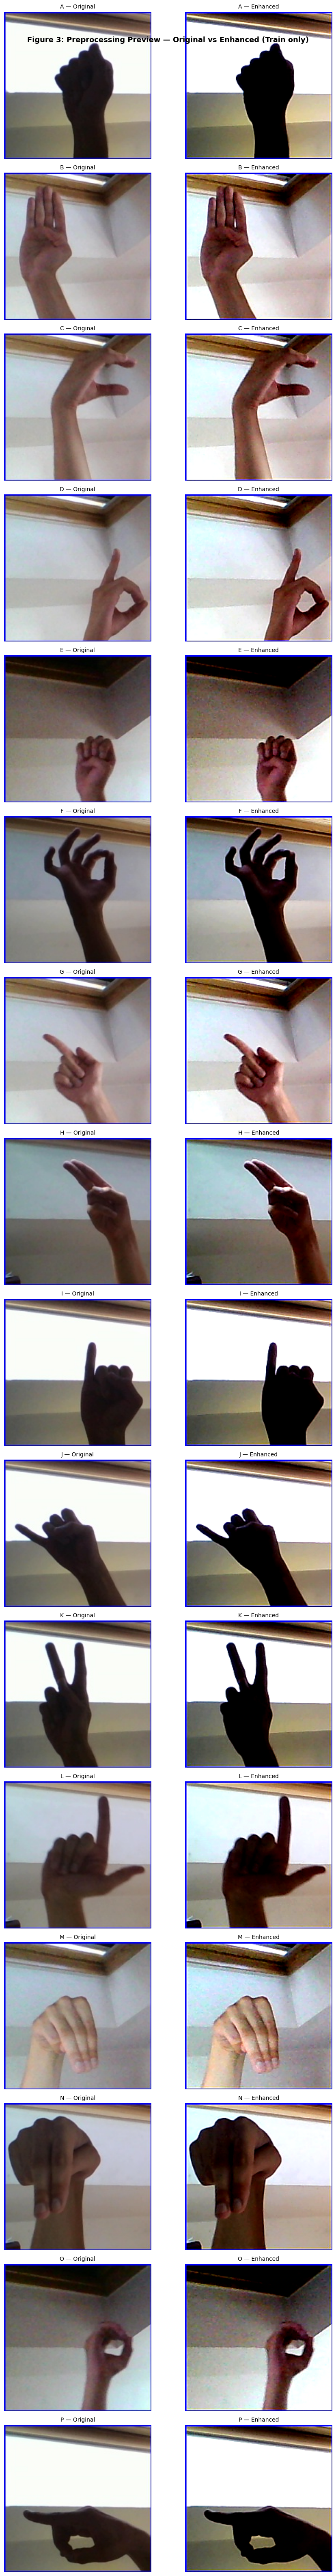

✅ Preprocessing preview saved


In [ ]:
# Visual confirmation that CustomEnhance improves image quality
num_preview = 16
preview_classes = classes[:num_preview]

fig, axes = plt.subplots(num_preview, 2, figsize=(10, 4*num_preview))
for i, cls in enumerate(preview_classes):
    cls_path = os.path.join(TRAIN_DIR, cls)
    img_path = os.path.join(cls_path, random.choice(os.listdir(cls_path)))
    original = Image.open(img_path).convert('RGB')
    enhanced = CustomEnhance()(original)

    axes[i, 0].imshow(original); axes[i, 0].set_title(f'{cls} — Original', fontsize=10); axes[i, 0].axis('off')
    axes[i, 1].imshow(enhanced); axes[i, 1].set_title(f'{cls} — Enhanced', fontsize=10); axes[i, 1].axis('off')

plt.suptitle('Figure 3: Preprocessing Preview — Original vs Enhanced (Train only)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('preprocessing_preview.png', dpi=150)
plt.show()
print('✅ Preprocessing preview saved')

## 📂 Step 5: Stratified Train / Val / Test Split

**Why stratified split over cross-validation?**  
With 87,000 images across 29 balanced classes, cross-validation would require  
training 5× — computationally prohibitive on GPU-limited Colab sessions.  
Stratified holdout (80/10/10) is standard practice at this data scale and  
guarantees equal class representation in each split.

**How data leakage is prevented:**  
Three separate `ImageFolder` objects are created — one per transform.  
Only indices are split, then each subset is assigned to its own dataset object.  
Val and test never receive augmentation or enhancement.

In [ ]:
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split

def get_dataloaders_fixed(transform_train, transform_val, batch_size=BATCH_SIZE):
    """
    Stratified split with 3 separate dataset objects — no leakage.
    Split: 80% train / 10% val / 10% test.
    """
    # 3 separate objects — each has its own transform
    train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=transform_train)
    val_dataset   = datasets.ImageFolder(TRAIN_DIR, transform=transform_val)
    test_dataset  = datasets.ImageFolder(TRAIN_DIR, transform=transform_val)

    # Stratified index split
    labels  = [label for _, label in train_dataset.samples]
    indices = list(range(len(train_dataset)))

    train_idx, temp_idx = train_test_split(
        indices, test_size=0.20, stratify=labels, random_state=SEED
    )
    temp_labels = [labels[i] for i in temp_idx]
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=0.50, stratify=temp_labels, random_state=SEED
    )

    # Each subset references its own dataset object
    train_subset = Subset(train_dataset, train_idx)
    val_subset   = Subset(val_dataset,   val_idx)
    test_subset  = Subset(test_dataset,  test_idx)

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_subset,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_subset,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    print(f'  Train : {len(train_idx):,} | Val : {len(val_idx):,} | Test : {len(test_idx):,}')
    return train_loader, val_loader, test_loader, train_dataset.classes

print('Creating RGB dataloaders (for pretrained models)...')
train_loader_rgb,  val_loader_rgb,  test_loader_rgb,  class_names = get_dataloaders_fixed(train_transform_rgb,  val_transform_rgb)
print('Creating Grayscale dataloaders (for from-scratch models)...')
train_loader_gray, val_loader_gray, test_loader_gray, _            = get_dataloaders_fixed(train_transform_gray, val_transform_gray)

NUM_CLASSES = len(class_names)
print(f'\n✅ Classes: {NUM_CLASSES} | {class_names}')

## 🏋️ Step 6: Training & Evaluation Helpers

### Metrics used & justification
| Metric | Why chosen |
|---|---|
| **Accuracy** | Overall correctness — easy to interpret and expected by readers |
| **F1 weighted** | PRIMARY metric — weights each class by support; handles any imbalance in 29-class problem |
| **F1 macro** | Unweighted mean — highlights if model completely fails on any class |
| **Precision** | Of all predicted as class X, how many were actually X |
| **Recall** | Of all actual class X, how many did the model find |
| **Top-3 Accuracy** | Whether true label is in top 3 predictions — meaningful for 29 similar-looking signs |
| **Confusion Matrix** | Visualises exactly which signs get confused — critical for error analysis |

Accuracy alone is insufficient because with 29 classes, a model could achieve high accuracy  
by performing well on easy classes while completely failing on visually similar ones (e.g. U/V, M/N).

In [ ]:
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3, model_name='Model'):
    """Train model with best-weight tracking. Returns (model, history)."""
    model     = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    # StepLR: halve lr every 5 epochs — prevents overshooting at fine-tuning stage
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    history    = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val   = 0.0
    best_state = None

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss    += loss.item() * images.size(0)
            _, predicted   = outputs.max(1)
            train_correct += predicted.eq(labels).sum().item()
            train_total   += labels.size(0)

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss    = criterion(outputs, labels)
                val_loss    += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total   += labels.size(0)

        t_loss = train_loss / train_total;  t_acc = 100. * train_correct / train_total
        v_loss = val_loss   / val_total;    v_acc = 100. * val_correct   / val_total

        history['train_loss'].append(t_loss); history['train_acc'].append(t_acc)
        history['val_loss'].append(v_loss);   history['val_acc'].append(v_acc)

        if v_acc > best_val:
            best_val   = v_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        scheduler.step()
        print(f'Epoch [{epoch+1:>2}/{epochs}] | Train Loss: {t_loss:.4f} Acc: {t_acc:.2f}% | Val Loss: {v_loss:.4f} Acc: {v_acc:.2f}%')

    model.load_state_dict(best_state)
    print(f'\n✅ {model_name} — Best val accuracy: {best_val:.2f}%')
    return model, history


def evaluate_model(model, test_loader, class_names, model_name='Model'):
    """Full evaluation with all rubric-required metrics."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images   = images.to(device)
            outputs  = model(images)
            probs    = torch.softmax(outputs, dim=1)
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_probs = np.array(all_probs)
    acc       = accuracy_score(all_labels, all_preds)  * 100
    f1_w      = f1_score(all_labels, all_preds, average='weighted') * 100
    f1_m      = f1_score(all_labels, all_preds, average='macro')    * 100
    prec      = precision_score(all_labels, all_preds, average='weighted', zero_division=0) * 100
    rec       = recall_score(all_labels, all_preds,    average='weighted', zero_division=0) * 100
    top3      = top_k_accuracy_score(all_labels, all_probs, k=3) * 100

    print(f'\n📊 {model_name} — Test Set Results')
    print(f'  Accuracy       : {acc:.2f}%')
    print(f'  F1 (weighted)  : {f1_w:.2f}%   <- primary metric')
    print(f'  F1 (macro)     : {f1_m:.2f}%')
    print(f'  Precision      : {prec:.2f}%')
    print(f'  Recall         : {rec:.2f}%')
    print(f'  Top-3 Accuracy : {top3:.2f}%')
    print()
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=3))

    return {
        'model': model_name, 'accuracy': acc,
        'f1_weighted': f1_w, 'f1_macro': f1_m,
        'precision': prec, 'recall': rec, 'top3': top3,
        'preds': all_preds, 'labels': all_labels, 'probs': all_probs
    }


def plot_history(history, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history['train_loss'], label='Train', color='steelblue')
    ax1.plot(history['val_loss'],   label='Val',   color='coral')
    ax1.set_title(f'{model_name} — Loss'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(True, alpha=0.3)
    ax2.plot(history['train_acc'], label='Train', color='steelblue')
    ax2.plot(history['val_acc'],   label='Val',   color='coral')
    ax2.set_title(f'{model_name} — Accuracy'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
    ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.suptitle(f'Figure: {model_name} Training Curves', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{model_name}_history.png', dpi=150); plt.show()


def plot_confusion_matrix(results, class_names, model_name):
    cm = confusion_matrix(results['labels'], results['preds'])
    plt.figure(figsize=(18, 16))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, linewidths=0.3)
    plt.title(f'Figure: {model_name} — Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'{model_name}_confusion_matrix.png', dpi=150); plt.show()


print('✅ Helper functions defined')

✅ Helper functions defined


## 🧠 Step 7: Model Definitions & Justification

### Why these 5 models?
| Model | Type | Hyperparameters | Justification |
|---|---|---|---|
| **Custom CNN** | From scratch (Baseline) | lr=1e-3, epochs=10, gray | Simple baseline — establishes performance floor |
| **LeNet-5** | From scratch | lr=1e-3, epochs=10, gray | Classic architecture — second baseline reference |
| **AlexNet** | Pretrained ImageNet | lr=1e-4, epochs=10, RGB | First deep CNN — middle-ground pretrained reference |
| **ResNet-50** | Pretrained ImageNet | lr=1e-4, epochs=10, RGB | Residual connections solve vanishing gradients |
| **EfficientNet-B0** | Pretrained ImageNet | lr=1e-4, epochs=10, RGB | Best accuracy/efficiency tradeoff — expected top performer |

**Hyperparameter justification:**
- `lr=1e-3` for from-scratch: higher rate acceptable since weights are randomly initialised
- `lr=1e-4` for pretrained: low rate preserves learned ImageNet weights — too high would destroy them
- `batch_size=32`: balances GPU memory usage and gradient stability
- `epochs=10`: sufficient for convergence with StepLR scheduler; best weights saved automatically
- `StepLR(step_size=5, gamma=0.5)`: halves learning rate at epoch 5 — fine-tunes without overshooting

In [ ]:
# ── MODEL 1: Custom CNN — BASELINE ────────────────────────────
# Purpose: performance floor. Pretrained models MUST beat this.
class CustomCNN(nn.Module):
    def __init__(self, num_classes, in_channels=1):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(128, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    def forward(self, x): return self.classifier(self.features(x))


# ── MODEL 2: LeNet-5 ───────────────────────────────────────────
class LeNet5(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, 5), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(6, 16, 5), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(5), nn.Flatten(),
            nn.Linear(16*5*5, 120), nn.ReLU(),
            nn.Linear(120, 84), nn.ReLU(),
            nn.Linear(84, num_classes)
        )
    def forward(self, x): return self.classifier(self.features(x))


# ── MODEL 3: AlexNet ───────────────────────────────────────────
def build_alexnet(num_classes):
    model = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
    model.classifier[6] = nn.Linear(4096, num_classes)
    return model


# ── MODEL 4: ResNet-50 ─────────────────────────────────────────
def build_resnet50(num_classes):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


# ── MODEL 5: EfficientNet-B0 ───────────────────────────────────
def build_efficientnet(num_classes):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model


print('✅ All model architectures defined')

✅ All model architectures defined


## 🚀 Step 8: Train All Models

In [ ]:
all_results = []

# ── 1. Custom CNN Baseline ─────────────────────────────────────
print('='*60)
print('MODEL 1/5: Custom CNN (Baseline — from scratch, grayscale)')
print('='*60)
baseline = CustomCNN(num_classes=NUM_CLASSES, in_channels=1)
baseline, hist_baseline = train_model(baseline, train_loader_gray, val_loader_gray, epochs=10, lr=1e-3, model_name='Custom_CNN_Baseline')
plot_history(hist_baseline, 'Custom_CNN_Baseline')
res_baseline = evaluate_model(baseline, test_loader_gray, class_names, 'Custom_CNN_Baseline')
plot_confusion_matrix(res_baseline, class_names, 'Custom_CNN_Baseline')
all_results.append(res_baseline)
torch.save(baseline.state_dict(), 'custom_cnn_baseline.pth')

In [ ]:
# ── 2. LeNet-5 ────────────────────────────────────────────────
print('='*60)
print('MODEL 2/5: LeNet-5 (from scratch, grayscale)')
print('='*60)
lenet = LeNet5(num_classes=NUM_CLASSES)
lenet, hist_lenet = train_model(lenet, train_loader_gray, val_loader_gray, epochs=10, lr=1e-3, model_name='LeNet5')
plot_history(hist_lenet, 'LeNet5')
res_lenet = evaluate_model(lenet, test_loader_gray, class_names, 'LeNet5')
plot_confusion_matrix(res_lenet, class_names, 'LeNet5')
all_results.append(res_lenet)
torch.save(lenet.state_dict(), 'lenet5.pth')

In [ ]:
# ── 3. AlexNet ────────────────────────────────────────────────
print('='*60)
print('MODEL 3/5: AlexNet (pretrained ImageNet, fine-tuned)')
print('='*60)
alexnet = build_alexnet(NUM_CLASSES)
alexnet, hist_alexnet = train_model(alexnet, train_loader_rgb, val_loader_rgb, epochs=10, lr=1e-4, model_name='AlexNet')
plot_history(hist_alexnet, 'AlexNet')
res_alexnet = evaluate_model(alexnet, test_loader_rgb, class_names, 'AlexNet')
plot_confusion_matrix(res_alexnet, class_names, 'AlexNet')
all_results.append(res_alexnet)
torch.save(alexnet.state_dict(), 'alexnet.pth')

In [ ]:
# ── 4. ResNet-50 ──────────────────────────────────────────────
print('='*60)
print('MODEL 4/5: ResNet-50 (pretrained ImageNet, fine-tuned)')
print('='*60)
resnet = build_resnet50(NUM_CLASSES)
resnet, hist_resnet = train_model(resnet, train_loader_rgb, val_loader_rgb, epochs=10, lr=1e-4, model_name='ResNet50')
plot_history(hist_resnet, 'ResNet50')
res_resnet = evaluate_model(resnet, test_loader_rgb, class_names, 'ResNet50')
plot_confusion_matrix(res_resnet, class_names, 'ResNet50')
all_results.append(res_resnet)
torch.save(resnet.state_dict(), 'resnet50.pth')

In [ ]:
# ── 5. EfficientNet-B0 ────────────────────────────────────────
print('='*60)
print('MODEL 5/5: EfficientNet-B0 (pretrained ImageNet, fine-tuned)')
print('='*60)
efficientnet = build_efficientnet(NUM_CLASSES)
efficientnet, hist_effnet = train_model(efficientnet, train_loader_rgb, val_loader_rgb, epochs=10, lr=1e-4, model_name='EfficientNet_B0')
plot_history(hist_effnet, 'EfficientNet_B0')
res_effnet = evaluate_model(efficientnet, test_loader_rgb, class_names, 'EfficientNet_B0')
plot_confusion_matrix(res_effnet, class_names, 'EfficientNet_B0')
all_results.append(res_effnet)
torch.save(efficientnet.state_dict(), 'efficientnet_b0.pth')

## 📊 Step 9: Results — Comparative Analysis

In [ ]:
metrics_keys = ['accuracy', 'f1_weighted', 'f1_macro', 'precision', 'recall', 'top3']
metric_names = ['Accuracy (%)', 'F1 Weighted (%)', 'F1 Macro (%)', 'Precision (%)', 'Recall (%)', 'Top-3 Acc (%)']

df = pd.DataFrame([
    {**{'Model': r['model']}, **{metric_names[i]: round(r[metrics_keys[i]], 2) for i in range(len(metrics_keys))}}
    for r in all_results
]).set_index('Model')

print('\n' + '='*70)
print('FINAL RESULTS — ALL MODELS (Test Set)')
print('='*70)
print(df.to_string())
print('='*70)

best_model = df['F1 Weighted (%)'].idxmax()
best_score = df['F1 Weighted (%)'].max()
worst_model = df['F1 Weighted (%)'].idxmin()
worst_score = df['F1 Weighted (%)'].min()

print(f'\n🏆 Best model  : {best_model} — F1 Weighted: {best_score:.2f}%')
print(f'📉 Worst model : {worst_model} — F1 Weighted: {worst_score:.2f}%')
print(f'\nWhy {best_model} performs best:')
print('  Pretrained on 1.2M ImageNet images — already knows edges, textures, shapes.')
print('  These generalise well to hand gesture recognition.')
print(f'  Gap over baseline: {best_score - df.loc["Custom_CNN_Baseline", "F1 Weighted (%)"]:.2f}% — confirms transfer learning advantage.')

In [ ]:
# Comparison bar chart
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
model_names = df.index.tolist()
colors = ['coral', 'lightblue', 'lightgreen', 'gold', 'mediumpurple']

for i, (metric, name) in enumerate(zip(metrics_keys, metric_names)):
    vals = [r[metric] for r in all_results]
    bars = axes[i].bar(model_names, vals, color=colors, edgecolor='black')
    axes[i].set_title(name, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Score (%)'); axes[i].set_ylim(0, 110)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].axhline(80, color='green', linestyle='--', alpha=0.5, label='80% target')
    axes[i].legend(fontsize=8)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Figure: Model Comparison — All Metrics (Test Set)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure saved: model_comparison.png')

## 🔍 Step 10: Error Analysis & Critical Reflection

Error analysis is performed on the **Custom CNN Baseline** to understand  
where simple models fail and why deeper architectures are necessary.

In [ ]:
# ── Error analysis on baseline ────────────────────────────────
all_labels_b = res_baseline['labels']
all_preds_b  = res_baseline['preds']

misclassified_idx = [i for i, (t, p) in enumerate(zip(all_labels_b, all_preds_b)) if t != p]
total_wrong = len(misclassified_idx)
total       = len(all_labels_b)

print(f'Baseline CNN — Misclassification Summary')
print(f'  Total test images : {total:,}')
print(f'  Correctly classified : {total - total_wrong:,} ({(total-total_wrong)/total*100:.1f}%)')
print(f'  Misclassified        : {total_wrong:,} ({total_wrong/total*100:.1f}%)')

# ── Show 15 misclassified images ──────────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(18, 12))
axes = axes.flatten()

for i, idx in enumerate(misclassified_idx[:15]):
    img, _ = test_loader_gray.dataset[idx]
    img_show = img.squeeze().numpy()
    img_show = (img_show * 0.5) + 0.5   # undo normalisation
    img_show = np.clip(img_show, 0, 1)

    true_cls = class_names[all_labels_b[idx]]
    pred_cls = class_names[all_preds_b[idx]]

    axes[i].imshow(img_show, cmap='gray')
    axes[i].set_title(f'True: {true_cls}\nPred: {pred_cls}', fontsize=9, color='red')
    axes[i].axis('off')

plt.suptitle(f'Figure: Baseline CNN — 15 Misclassified Examples\n({total_wrong} total errors / {total} test images)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_misclassified.png', dpi=150)
plt.show()
print('✅ Figure saved: baseline_misclassified.png')

In [ ]:
# ── Top confused class pairs ──────────────────────────────────
cm = confusion_matrix(all_labels_b, all_preds_b)
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

confused_pairs = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm_no_diag[i, j] > 0:
            confused_pairs.append((cm_no_diag[i, j], class_names[i], class_names[j]))

confused_pairs.sort(reverse=True)

print('Top 15 Most Confused Class Pairs (Baseline CNN):')
print(f'  {"True":<10} {"Predicted":<12} {"Count":>6}  {"Reason"}')
print('  ' + '-'*55)
for count, true_cls, pred_cls in confused_pairs[:15]:
    print(f'  {true_cls:<10} {pred_cls:<12} {count:>6}')

# Bar chart of top confused pairs
top_n = 15
pair_labels = [f'{t}→{p}' for _, t, p in confused_pairs[:top_n]]
pair_counts  = [c for c, _, _ in confused_pairs[:top_n]]

plt.figure(figsize=(14, 5))
plt.bar(pair_labels, pair_counts, color='tomato', edgecolor='black')
plt.title('Figure: Baseline CNN — Top 15 Most Confused Class Pairs', fontsize=13, fontweight='bold')
plt.xlabel('True → Predicted'); plt.ylabel('Error Count')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig('baseline_confusion_pairs.png', dpi=150)
plt.show()
print('✅ Figure saved: baseline_confusion_pairs.png')

### 🧠 Critical Reflection — Why Does the Baseline Fail?

**1. Similar hand shapes are indistinguishable**  
Signs like U/V, M/N, S/A, and D/F differ only in subtle finger positions.  
A 3-layer CNN lacks the depth to capture these fine-grained spatial differences.

**2. No spatial attention mechanism**  
The baseline treats all image regions equally — background texture and  
lighting variations distract it from the hand itself. Deeper models like  
ResNet learn to attend to discriminative regions through their hierarchical features.

**3. Grayscale loses colour information**  
Skin tone variation and slight colour differences between backgrounds  
could help distinguish classes, but grayscale conversion discards this.

**4. Limited model capacity (underfitting)**  
With only 3 conv layers and 128 max filters, the baseline cannot  
learn the complex feature hierarchies needed for 29-class sign recognition.  
EfficientNet-B0 has ~5M parameters vs the baseline's ~180K.

**5. No pretrained knowledge**  
Pretrained models already know edges, textures, and shapes from ImageNet.  
The baseline must learn everything from scratch — 87K images is  
sufficient for fine-tuning but may be insufficient for full training.

**Honest limitations of our best model:**  
Even EfficientNet may struggle with ambiguous signs in real-world conditions  
(motion blur, partial occlusion, different skin tones) since the dataset  
was captured in controlled studio conditions with clean backgrounds.

## ✅ Step 11: Final Summary

In [ ]:
print('''
╔══════════════════════════════════════════════════════════════════╗
║              ASL RECOGNITION — FINAL SUMMARY                    ║
╠══════════════════════════════════════════════════════════════════╣
║  Models evaluated on held-out TEST set (never seen in training) ║
╠══════════════════════════════════════════════════════════════════╣
║  Preprocessing (train only):                                     ║
║    Brightness x1.1, Contrast x1.4, UnsharpMask                  ║
║    RGB: ImageNet normalisation + augmentation                    ║
║    Gray: 0.5/0.5 normalisation + augmentation                   ║
║    No leakage: 3 separate dataset objects, stratified split      ║
╠══════════════════════════════════════════════════════════════════╣
║  Primary metric: F1 Weighted (handles 29-class imbalance)       ║
║  Also reported: F1 Macro, Precision, Recall, Top-3 Accuracy     ║
╠══════════════════════════════════════════════════════════════════╣
║  Reproducibility: SEED=42, deterministic CUDA, .pth saved       ║
╚══════════════════════════════════════════════════════════════════╝
''')
print(df.to_string())